In [1]:
#构造ResNet块
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [2]:
#查看输入和输出形状一致的情况
blk=Residual(3,3)
X=torch.rand(4,3,6,6)
Y=blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [3]:
#减半输出的高和宽的同时，输出通道数加倍
blk=Residual(3,6,use_1x1conv=True,strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

In [4]:
#实现这个模块，对第一个模块做特别处理
b1=nn.Sequential(nn.Conv2d(1,64,kernel_size=7,stride=2,padding=1),nn.BatchNorm2d(64),nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3,padding=1,stride=2))

def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

b2=nn.Sequential(*resnet_block(64,64,2,first_block=True))
b3=nn.Sequential(*resnet_block(64,128,2))
b4=nn.Sequential(*resnet_block(128,256,2))
b5=nn.Sequential(*resnet_block(256,512,2))

net=nn.Sequential(b1,b2,b3,b4,b5,nn.AdaptiveAvgPool2d((1,1)),nn.Flatten(),nn.Linear(512,10))

In [5]:
#观察网络情况
X=torch.rand(size=(1,1,224,224))
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape',X.shape)

Sequential output shape torch.Size([1, 64, 55, 55])
Sequential output shape torch.Size([1, 64, 55, 55])
Sequential output shape torch.Size([1, 128, 28, 28])
Sequential output shape torch.Size([1, 256, 14, 14])
Sequential output shape torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape torch.Size([1, 512, 1, 1])
Flatten output shape torch.Size([1, 512])
Linear output shape torch.Size([1, 10])


In [6]:
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size,resize=224)

In [7]:
def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,nn.Module):
        net.eval()
        if not device:
            device=next(iter(net.parameters())).device
    metric=d2l.Accumulator(2)
    for X,y in data_iter:
        if isinstance(X,list):
            X=[x.to(device) for x in X]
        else:
            X=X.to(device)
        y=y.to(device)
        metric.add(d2l.accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [8]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if isinstance(m,nn.Linear) or isinstance(m,nn.Conv2d):
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weight)
    print('training on:\t',device)
    net.to(device)
    optimizer=torch.optim.AdamW(net.parameters(),lr=lr)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

    for epoch in range(num_epochs):
        metric=d2l.Accumulator(5)
        net.train()
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            optimizer.step()
            metric.add(l.item()*X.shape[0],d2l.accuracy(net(X),y),X.shape[0])
            timer.stop()
            train_l=metric[0]/metric[2]
            train_acc=metric[1]/metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc=evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.020, train acc 0.996, test acc 0.914
606.4 examples/sec on cuda:0


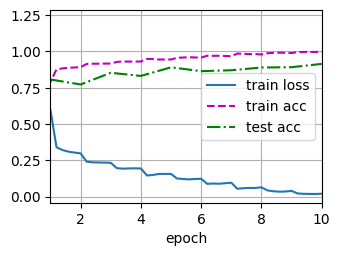

In [ ]:
#训练模型
lr,num_epochs,batch_size=0.05,10,256
train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())